In [ ]:
# ---
# title: "NoteBook pour générer des beaux grapiques"
# author: Asmaa
# format: html
# ---

### Méthodes d'insertion PostgreSQL
Comparaison des performances insertion : 1 000 / 100 000 / 1 000 000 lignes

1. Imports et configuration

In [30]:
import psycopg2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Style global des graphiques
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12


Connexion à la base de données

In [31]:
DB_CONFIG = {
    "dbname": "test",
    "user": "postgres",
    "password": "1201",
    "host": "localhost",
    "port": "5432"
}

conn   = psycopg2.connect(**DB_CONFIG)
cursor = conn.cursor()

print(" Connexion réussie")


 Connexion réussie


Chargement des données

In [32]:
query = """
SELECT
    pt.name  AS method,
    t.time   AS duration
FROM time t
JOIN push_type pt ON pt.push_id = t.push_id;
"""

df = pd.read_sql(query, conn)

print(f"Lignes chargées : {len(df):,}")
df.head()


Lignes chargées : 330


c:\Users\abide\anaconda3\lib\site-packages\pandas\io\sql.py:762: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(


,method,duration
0,thousand_naive,0.342629
1,thousand_naive,0.343203
2,thousand_naive,0.340084
3,thousand_naive,0.335102
4,thousand_naive,0.341335


Nettoyage et typage

In [33]:
df = df.dropna()
df["duration"] = df["duration"].astype(float)

print(df.info())
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 330 entries, 0 to 329
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   method    330 non-null    object 
 1   duration  330 non-null    float64
dtypes: float64(1), object(1)
memory usage: 5.3+ KB
None


,duration
count,330.000000
mean,17.322007
std,44.923472
min,0.007643
25%,0.330937
50%,0.741668
75%,10.861933
max,263.358773


Segmentation par volume

On filtre chaque sous-groupe à partir du nom de la méthode.

In [34]:
def filter_by_size(df, *keywords):
    """Garde les lignes dont le nom de méthode contient l'un des mots-clés."""
    pattern = "|".join(keywords)
    return df[df["method"].str.contains(pattern, case=False)].copy()

df_1k   = df[df["method"].str.contains(r"1k|thousand", case=False)].copy()
df_100k = df[df["method"].str.contains(r"100k", case=False)].copy()
df_1m   = df[df["method"].str.contains(r"1M", case=False)].copy()

print("1 000 lignes  :", df_1k.shape)
print("100 000 lignes:", df_100k.shape)
print("1 M lignes    :", df_1m.shape)


1 000 lignes  : (150, 2)
100 000 lignes: (100, 2)
1 M lignes    : (80, 2)


In [35]:
print(df["method"].unique())

['thousand_naive' 'thousand_unique' 'Executemany 1k' 'Executemany 100k'
 'Executemany 1M' 'Execute_batch 1k (page_size=100)'
 'Execute_batch 100k (page_size=1000)'
 'Execute_batch 100k (page_size=10000)'
 'Execute_batch 1M (page_size=10000)' 'COPY Expert 1k' 'COPY Expert 100k'
 'COPY Expert 1M' 'Pandas Default 1k' 'Pandas Multi 1k'
 'Pandas Multi 100k' 'Pandas Multi 1M' 'Pandas Callable COPY 1k'
 'Pandas Callable COPY 100k' 'Pandas Callable COPY 1M'
 'COPY Stream Tuple 1k' 'COPY Stream Tuple 100k' 'COPY Stream Tuple 1M']


Statistiques descriptives

In [36]:
summary = (
    df.groupby("method")["duration"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .sort_values("mean")
    .round(4)
)

summary

,count,mean,median,std,min,max
method,,,,,,
COPY Expert 1k,10,0.0080,0.0080,0.0003,0.0076,0.0086
COPY Stream Tuple 1k,10,0.0110,0.0111,0.0011,0.0090,0.0126
Execute_batch 1k (page_size=100),20,0.0260,0.0254,0.0024,0.0224,0.0321
Pandas Callable COPY 1k,10,0.0764,0.0589,0.0388,0.0558,0.1610
Executemany 1k,20,0.1112,0.1113,0.0021,0.1052,0.1138
Pandas Default 1k,10,0.1840,0.1643,0.0407,0.1584,0.2683
thousand_naive,30,0.3415,0.3415,0.0052,0.3305,0.3513
thousand_unique,30,0.3459,0.3454,0.0048,0.3359,0.3538
Pandas Multi 1k,10,0.3750,0.3509,0.0556,0.3209,0.4699


Visualisations comparatives

Temps moyen par méthode (barplot)

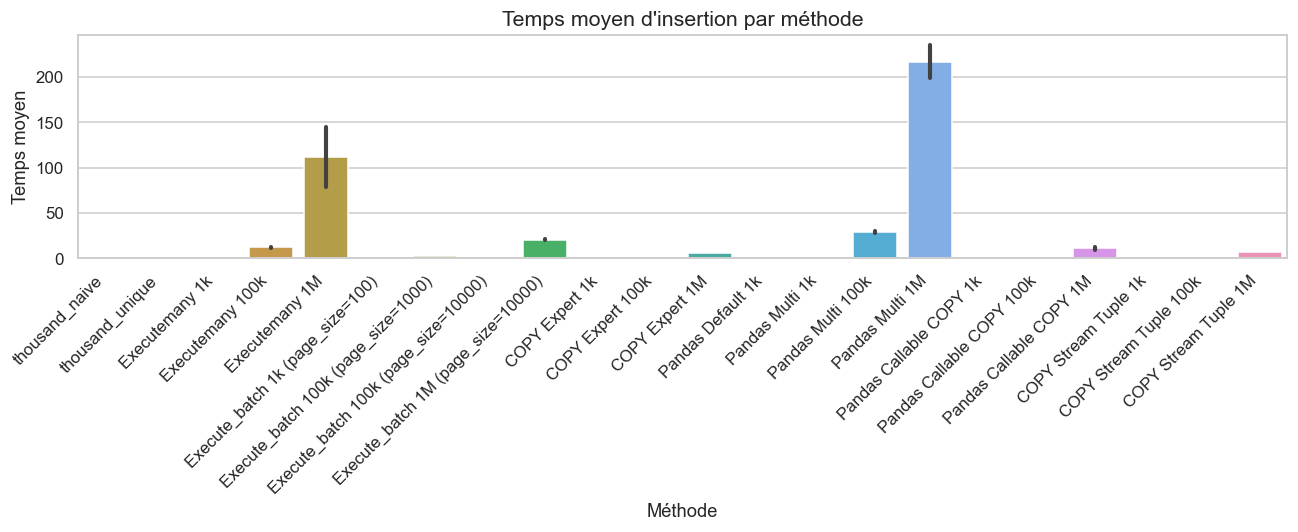

In [37]:
plt.figure(figsize=(12, 5))

sns.barplot(data=df, x="method", y="duration", estimator="mean", errorbar="sd")

plt.title("Temps moyen d'insertion par méthode")
plt.xlabel("Méthode")
plt.ylabel("Temps moyen")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


ECDF comparatif (toutes méthodes)

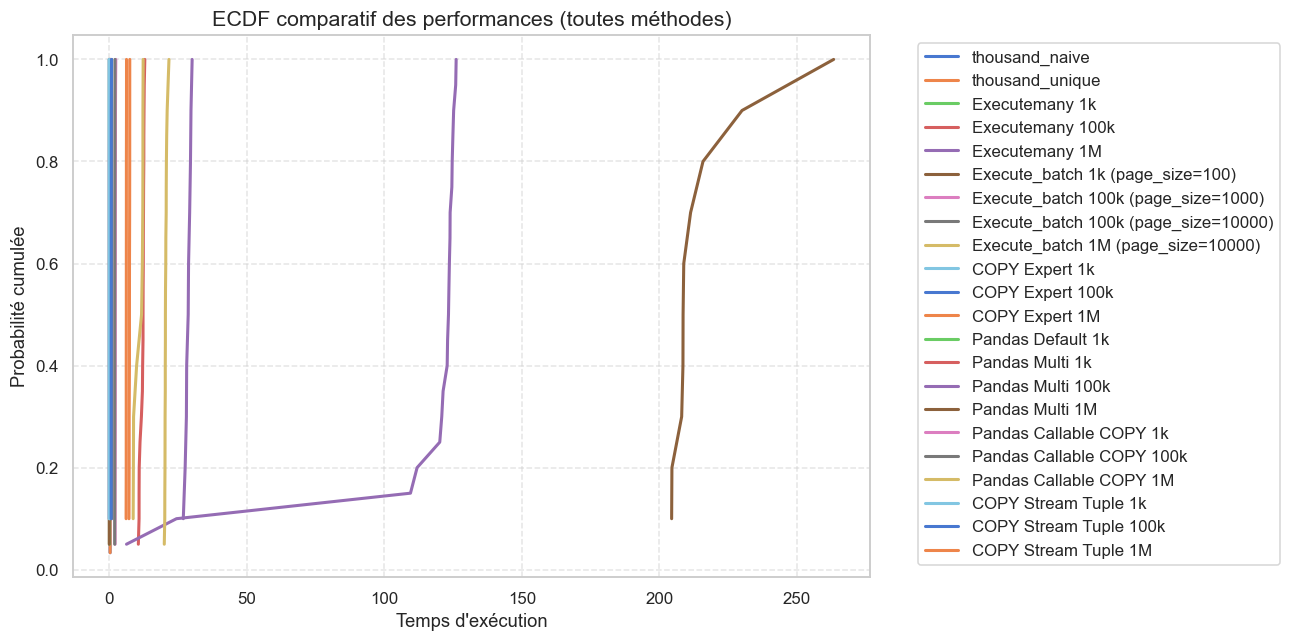

In [38]:
def ecdf(data):
    """Retourne les coordonnées (x, y) de la fonction de répartition empirique."""
    x = np.sort(data)
    y = np.arange(1, len(x) + 1) / len(x)
    return x, y

plt.figure(figsize=(12, 6))

for method in df["method"].dropna().unique():
    subset = df[df["method"] == method]["duration"].dropna()
    if len(subset) < 5:
        continue
    x, y = ecdf(subset)
    plt.plot(x, y, linewidth=2, label=method)

plt.title("ECDF comparatif des performances (toutes méthodes)")
plt.xlabel("Temps d'exécution")
plt.ylabel("Probabilité cumulée")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


###  Courbe des performances moyennes

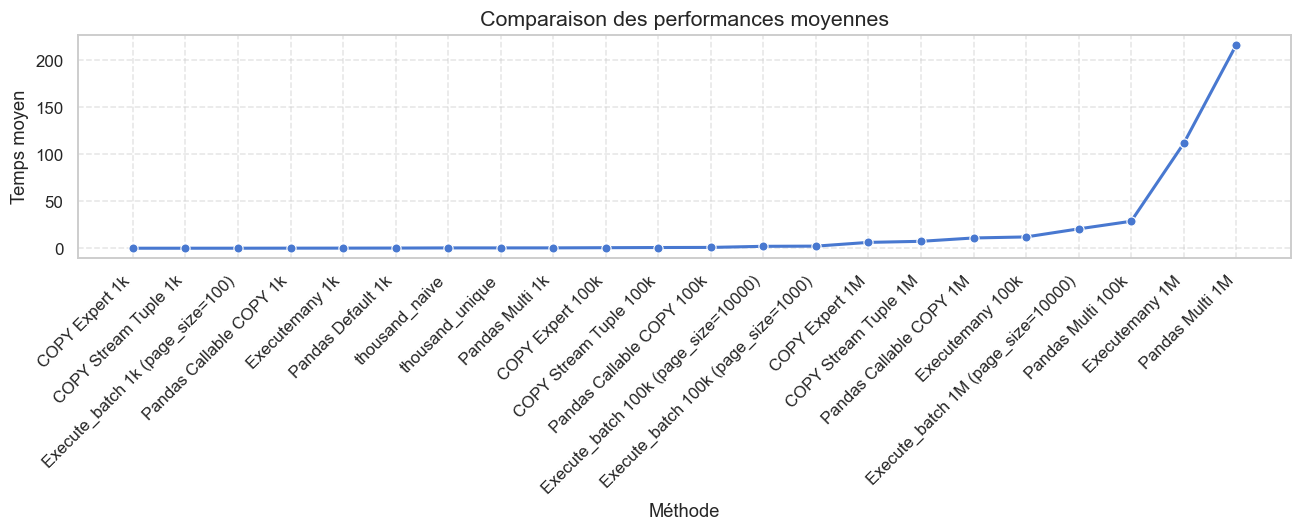

In [39]:
mean_df = df.groupby("method", as_index=False)["duration"].mean().sort_values("duration")

plt.figure(figsize=(12, 5))

sns.lineplot(data=mean_df, x="method", y="duration", marker="o", linewidth=2)

plt.title("Comparaison des performances moyennes")
plt.xlabel("Méthode")
plt.ylabel("Temps moyen")
plt.xticks(rotation=45, ha="right")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


## 8. Comparaison des méthodes

On visualise comment chaque méthode se comporte selon la taille du jeu de données.


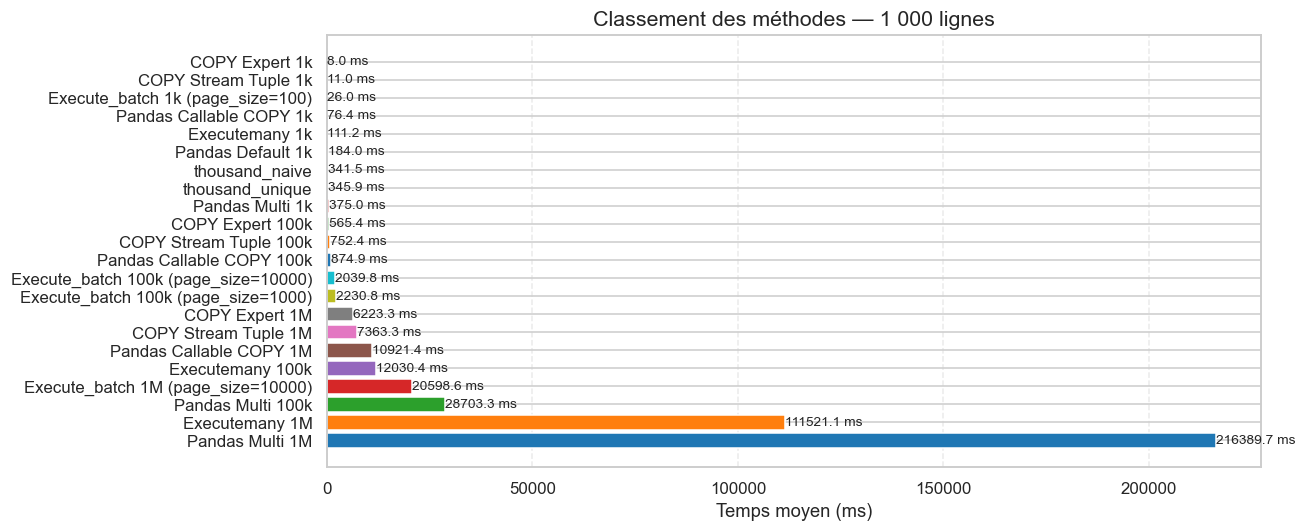

In [40]:
# Ajout d'un libellé de volume pour chaque sous-groupe
df_1k["volume"]   = "1 000"
df_100k["volume"] = "100 000"
df_1m["volume"]   = "1 000 000"

df_all = pd.concat([df_1k, df_100k, df_1m], ignore_index=True)

# Ordre logique des volumes
df_all["volume"] = pd.Categorical(
    df_all["volume"],
    categories=["1 000", "100 000", "1 000 000"],
    ordered=True
)

# Barplot horizontal — classement final
plt.figure(figsize=(12, 5))

ranked = summary["mean"].sort_values() * 1000

bars = plt.barh(ranked.index[::-1], ranked.values[::-1],
                color=plt.cm.tab10.colors[:len(ranked)])

for bar in bars:
    plt.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
             f"{bar.get_width():.1f} ms", va="center", fontsize=9)

plt.title("Classement des méthodes — 1 000 lignes")
plt.xlabel("Temps moyen (ms)")
plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


Classement final des méthodes

In [41]:
ranking = summary[["mean", "median", "std"]].sort_values("mean")

# Ajout d'un rang
ranking.insert(0, "rang", range(1, len(ranking) + 1))

print(" Classement des méthodes (du plus rapide au plus lent)")
ranking


 Classement des méthodes (du plus rapide au plus lent)


,rang,mean,median,std
method,,,,
COPY Expert 1k,1,0.0080,0.0080,0.0003
COPY Stream Tuple 1k,2,0.0110,0.0111,0.0011
Execute_batch 1k (page_size=100),3,0.0260,0.0254,0.0024
Pandas Callable COPY 1k,4,0.0764,0.0589,0.0388
Executemany 1k,5,0.1112,0.1113,0.0021
Pandas Default 1k,6,0.1840,0.1643,0.0407
thousand_naive,7,0.3415,0.3415,0.0052
thousand_unique,8,0.3459,0.3454,0.0048
Pandas Multi 1k,9,0.3750,0.3509,0.0556


###Visualisation des 1000

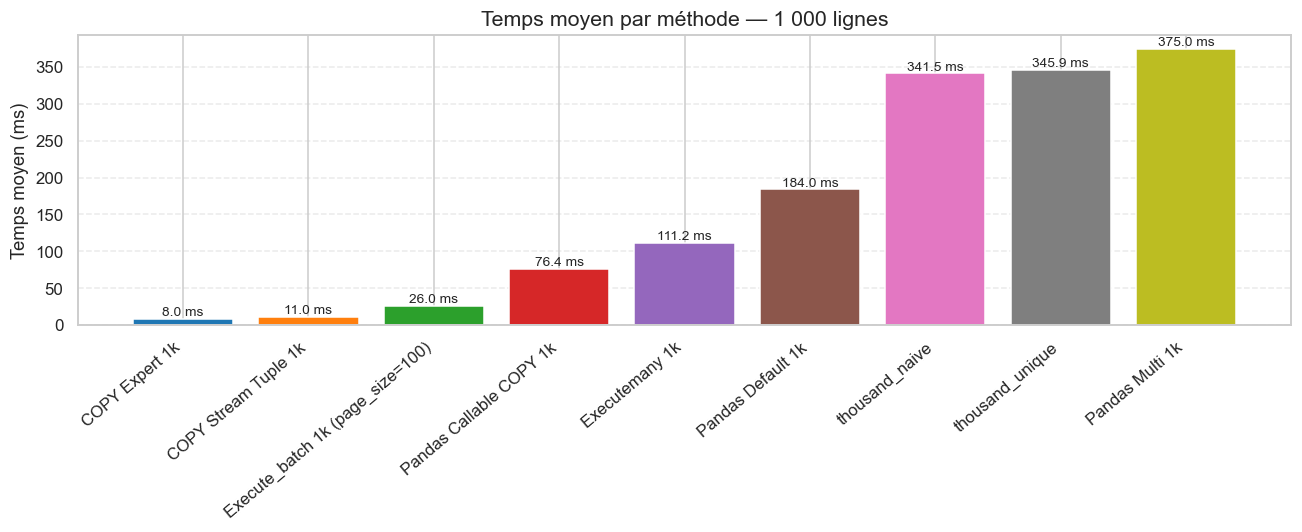

In [42]:
# Barplot — temps moyen par méthode (1 000 lignes)
plt.figure(figsize=(12, 5))

summary_1k = df_1k.groupby("method")["duration"].mean().sort_values() * 1000

bars = plt.bar(summary_1k.index, summary_1k.values,
               color=plt.cm.tab10.colors[:len(summary_1k)], edgecolor="white")

for bar in bars:
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.2,
             f"{bar.get_height():.1f} ms", ha="center", va="bottom", fontsize=9)

plt.title("Temps moyen par méthode — 1 000 lignes")
plt.ylabel("Temps moyen (ms)")
plt.xticks(rotation=40, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

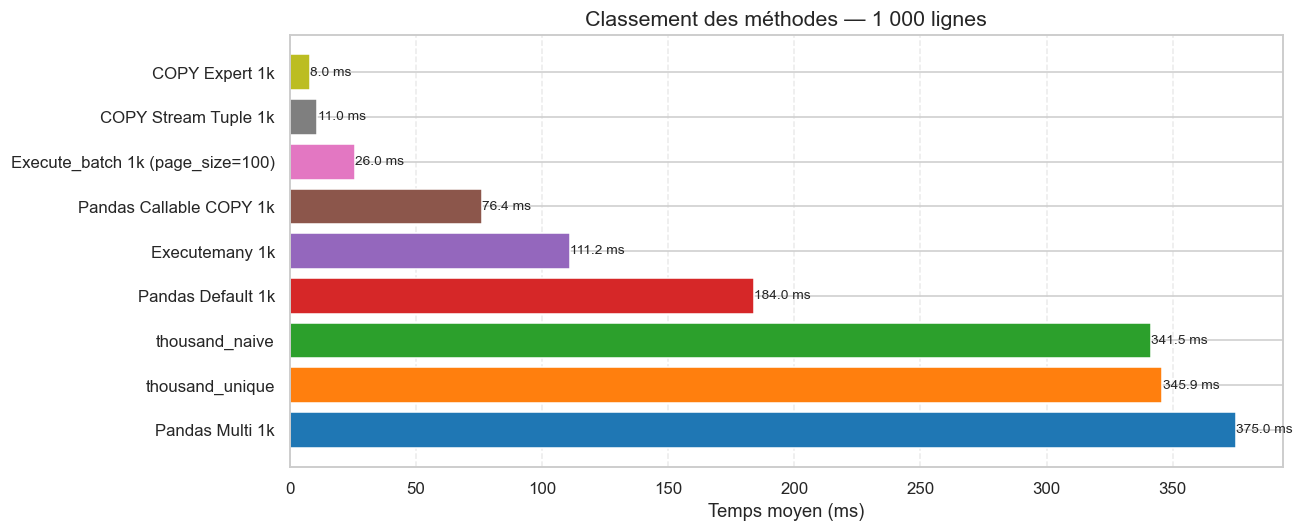

In [43]:
# Classement final (1 000 lignes)
plt.figure(figsize=(12, 5))

ranked_1k = df_1k.groupby("method")["duration"].mean().sort_values() * 1000

bars = plt.barh(ranked_1k.index[::-1], ranked_1k.values[::-1],
                color=plt.cm.tab10.colors[:len(ranked_1k)])

for bar in bars:
    plt.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
             f"{bar.get_width():.1f} ms", va="center", fontsize=9)

plt.title("Classement des méthodes — 1 000 lignes")
plt.xlabel("Temps moyen (ms)")
plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

100000

In [44]:
ranking_100k = (
    df_100k.groupby("method")["duration"]
    .agg(
        essais="count",
        moyenne="mean",
        mediane="median",
        ecart_type="std",
        minimum="min",
        maximum="max"
    )
    .sort_values("moyenne")
    .round(4)
)

ranking_100k

,essais,moyenne,mediane,ecart_type,minimum,maximum
method,,,,,,
COPY Expert 100k,10,0.5654,0.5660,0.0225,0.5239,0.6032
COPY Stream Tuple 100k,10,0.7524,0.7417,0.0404,0.7237,0.8597
Pandas Callable COPY 100k,10,0.8749,0.8721,0.0058,0.8708,0.8860
Execute_batch 100k (page_size=10000),20,2.0398,2.0281,0.0352,1.9950,2.1100
Execute_batch 100k (page_size=1000),20,2.2308,2.2199,0.0582,2.1488,2.3969
Executemany 100k,20,12.0304,12.3167,0.7315,10.5943,12.9460
Pandas Multi 100k,10,28.7033,28.7861,1.0116,26.9354,30.1520


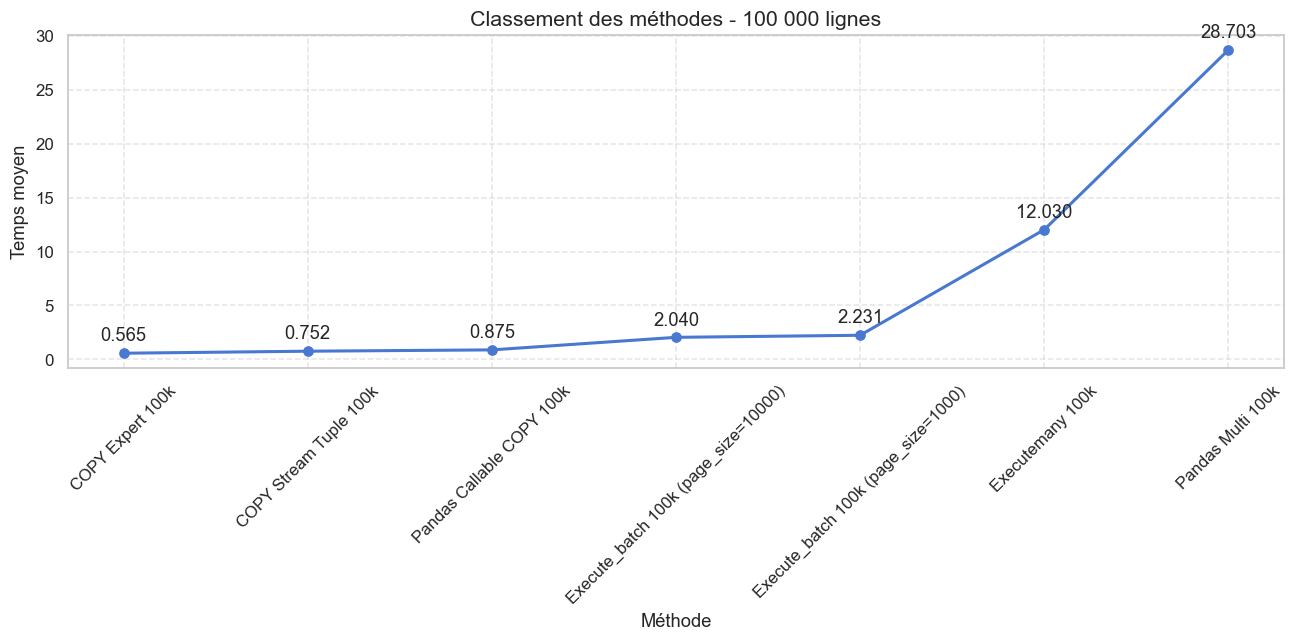

In [45]:
import matplotlib.pyplot as plt

ranking_plot = ranking_100k.reset_index()

plt.figure(figsize=(12,6))

plt.plot(
    ranking_plot["method"],
    ranking_plot["moyenne"],
    marker="o",
    linewidth=2
)

for x, y in zip(ranking_plot["method"], ranking_plot["moyenne"]):
    plt.annotate(
        f"{y:.3f}",
        (x, y),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center"
    )

plt.title("Classement des méthodes - 100 000 lignes")
plt.xlabel("Méthode")
plt.ylabel("Temps moyen")
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

1000000

In [46]:
ranking_1m = (
    df_1m.groupby("method")["duration"]
    .agg(
        essais="count",
        moyenne="mean",
        mediane="median",
        ecart_type="std",
        minimum="min",
        maximum="max"
    )
    .sort_values("moyenne")
)

ranking_1m

,essais,moyenne,mediane,ecart_type,minimum,maximum
method,,,,,,
COPY Expert 1M,10,6.223305,6.223749,0.047352,6.142195,6.295719
COPY Stream Tuple 1M,10,7.363280,7.368511,0.100982,7.188858,7.476091
Pandas Callable COPY 1M,10,10.921383,11.905639,1.627252,8.713129,12.347599
Execute_batch 1M (page_size=10000),20,20.598630,20.452403,0.420111,20.024968,21.728159
Executemany 1M,20,111.521114,123.421678,33.285066,6.290718,126.133935
Pandas Multi 1M,10,216.389744,208.751754,18.094474,204.467974,263.358773


In [47]:
ranking_1m = ranking_1m.round(4)

ranking_1m

,essais,moyenne,mediane,ecart_type,minimum,maximum
method,,,,,,
COPY Expert 1M,10,6.2233,6.2237,0.0474,6.1422,6.2957
COPY Stream Tuple 1M,10,7.3633,7.3685,0.1010,7.1889,7.4761
Pandas Callable COPY 1M,10,10.9214,11.9056,1.6273,8.7131,12.3476
Execute_batch 1M (page_size=10000),20,20.5986,20.4524,0.4201,20.0250,21.7282
Executemany 1M,20,111.5211,123.4217,33.2851,6.2907,126.1339
Pandas Multi 1M,10,216.3897,208.7518,18.0945,204.4680,263.3588


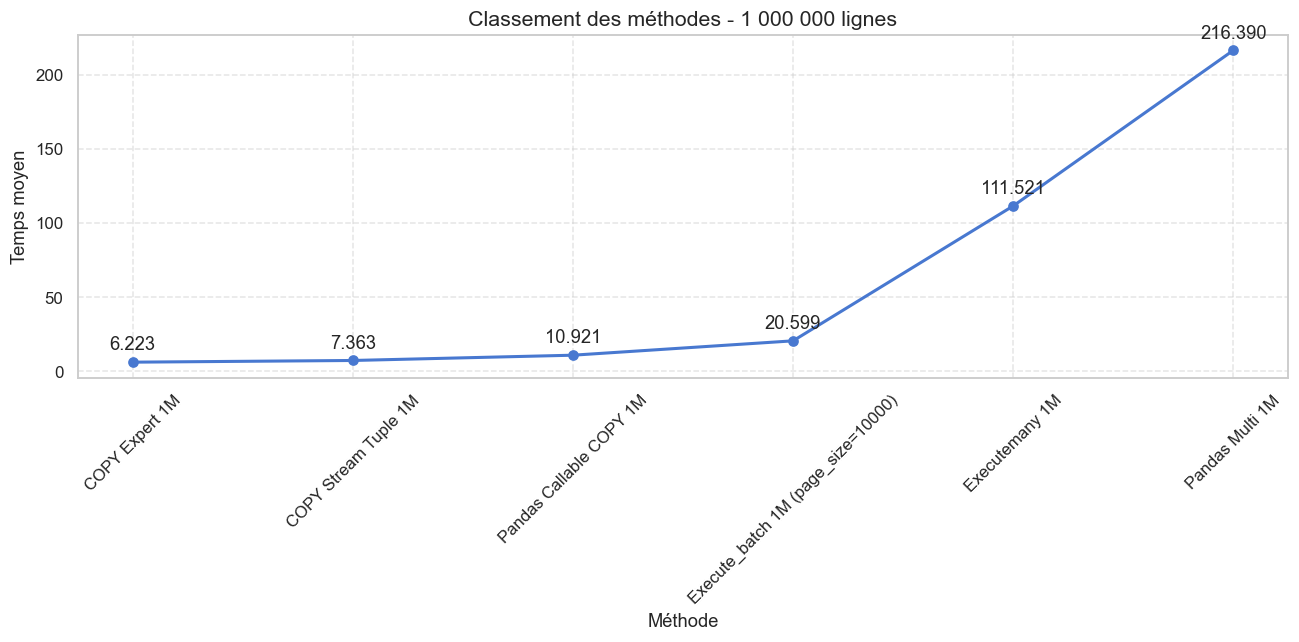

In [48]:
import matplotlib.pyplot as plt

ranking_plot = ranking_1m.reset_index()

plt.figure(figsize=(12,6))

plt.plot(
    ranking_plot["method"],
    ranking_plot["moyenne"],
    marker="o",
    linewidth=2
)

for x, y in zip(ranking_plot["method"], ranking_plot["moyenne"]):
    plt.annotate(
        f"{y:.3f}",
        (x, y),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center"
    )

plt.title("Classement des méthodes - 1 000 000 lignes")
plt.xlabel("Méthode")
plt.ylabel("Temps moyen")
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [49]:
best_time = ranking_1m["moyenne"].min()

ranking_1m["ratio_vs_best"] = (
    ranking_1m["moyenne"] / best_time
)

ranking_1m.sort_values("ratio_vs_best")

,essais,moyenne,mediane,ecart_type,minimum,maximum,ratio_vs_best
method,,,,,,,
COPY Expert 1M,10,6.2233,6.2237,0.0474,6.1422,6.2957,1.000000
COPY Stream Tuple 1M,10,7.3633,7.3685,0.1010,7.1889,7.4761,1.183183
Pandas Callable COPY 1M,10,10.9214,11.9056,1.6273,8.7131,12.3476,1.754921
Execute_batch 1M (page_size=10000),20,20.5986,20.4524,0.4201,20.0250,21.7282,3.309916
Executemany 1M,20,111.5211,123.4217,33.2851,6.2907,126.1339,17.919930
Pandas Multi 1M,10,216.3897,208.7518,18.0945,204.4680,263.3588,34.770893


Tableau recapitulatif

In [50]:
# Tableau récapitulatif : méthode × taille → temps médian
m1k   = df_1k.groupby("method")["duration"].median() * 1000
m100k = df_100k.groupby("method")["duration"].median() * 1000
m1m   = df_1m.groupby("method")["duration"].median() * 1000

tableau = pd.concat([m1k, m100k, m1m], axis=1, keys=["1 000", "100 000", "1 000 000"]).round(2)
tableau

,1 000,100 000,1 000 000
method,,,
COPY Expert 1k,7.97,NaN,NaN
COPY Stream Tuple 1k,11.10,NaN,NaN
Execute_batch 1k (page_size=100),25.39,NaN,NaN
Executemany 1k,111.34,NaN,NaN
Pandas Callable COPY 1k,58.94,NaN,NaN
Pandas Default 1k,164.29,NaN,NaN
Pandas Multi 1k,350.85,NaN,NaN
thousand_naive,341.46,NaN,NaN
thousand_unique,345.45,NaN,NaN


Les representations attendu du Brief

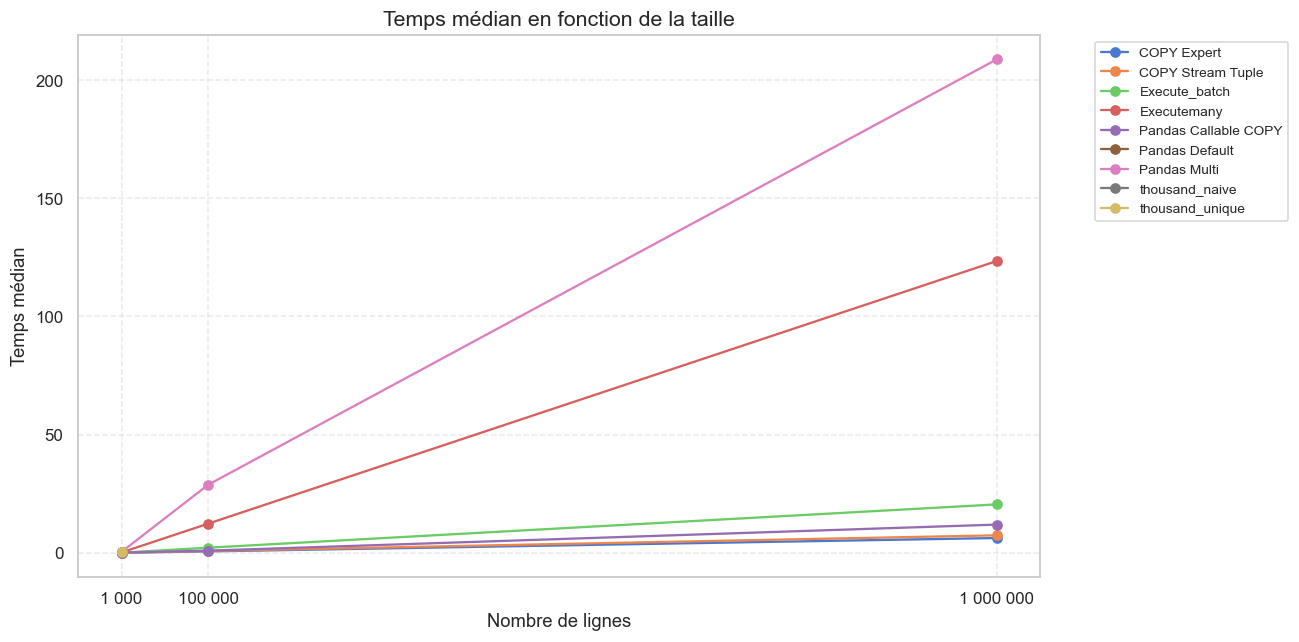

In [61]:
import re

# On ajoute une colonne "taille" et une colonne "famille" (nom sans la taille)
df["taille"] = df["method"].apply(
    lambda m: 1_000 if re.search(r"1k|thousand", m, re.IGNORECASE)
    else 100_000 if re.search(r"100k", m, re.IGNORECASE)
    else 1_000_000
)
df["famille"] = df["method"].str.replace(r"\s*(1k|100k|1M).*", "", regex=True)

# Médiane par famille et par taille
medianes = df.groupby(["famille", "taille"])["duration"].median().unstack()

plt.figure(figsize=(12, 6))

for famille in medianes.index:
    plt.plot(medianes.columns, medianes.loc[famille], marker="o", label=famille)

plt.title("Temps médian en fonction de la taille")
plt.xlabel("Nombre de lignes")
plt.ylabel("Temps médian")
plt.xticks([1_000, 100_000, 1_000_000], ["1 000", "100 000", "1 000 000"])
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=9)
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

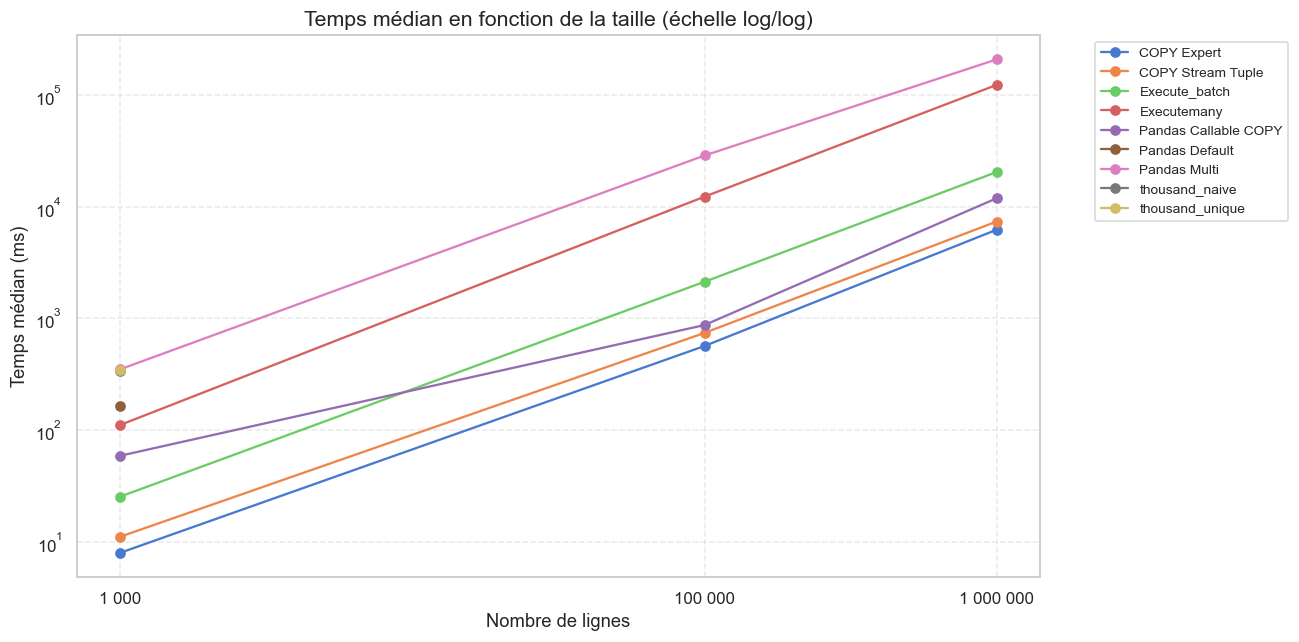

In [ ]:
import re
# On ajoute une colonne "taille" et une colonne "famille" (nom sans la taille)
df["taille"] = df["method"].apply(
    lambda m: 1_000 if re.search(r"1k|thousand", m, re.IGNORECASE)
    else 100_000 if re.search(r"100k", m, re.IGNORECASE)
    else 1_000_000
)
df["famille"] = df["method"].str.replace(r"\s*(1k|100k|1M).*", "", regex=True)

# Médiane par famille et par taille
medianes = df.groupby(["famille", "taille"])["duration"].median().unstack() * 1000

plt.figure(figsize=(12, 6))

for famille in medianes.index:
    plt.plot(medianes.columns, medianes.loc[famille], marker="o", label=famille)

plt.xscale("log")
plt.yscale("log")
plt.title("Temps médian en fonction de la taille (échelle log/log)")
plt.xlabel("Nombre de lignes")
plt.ylabel("Temps médian")
plt.xticks([1_000, 100_000, 1_000_000], ["1 000", "100 000", "1 000 000"])
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=9)
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

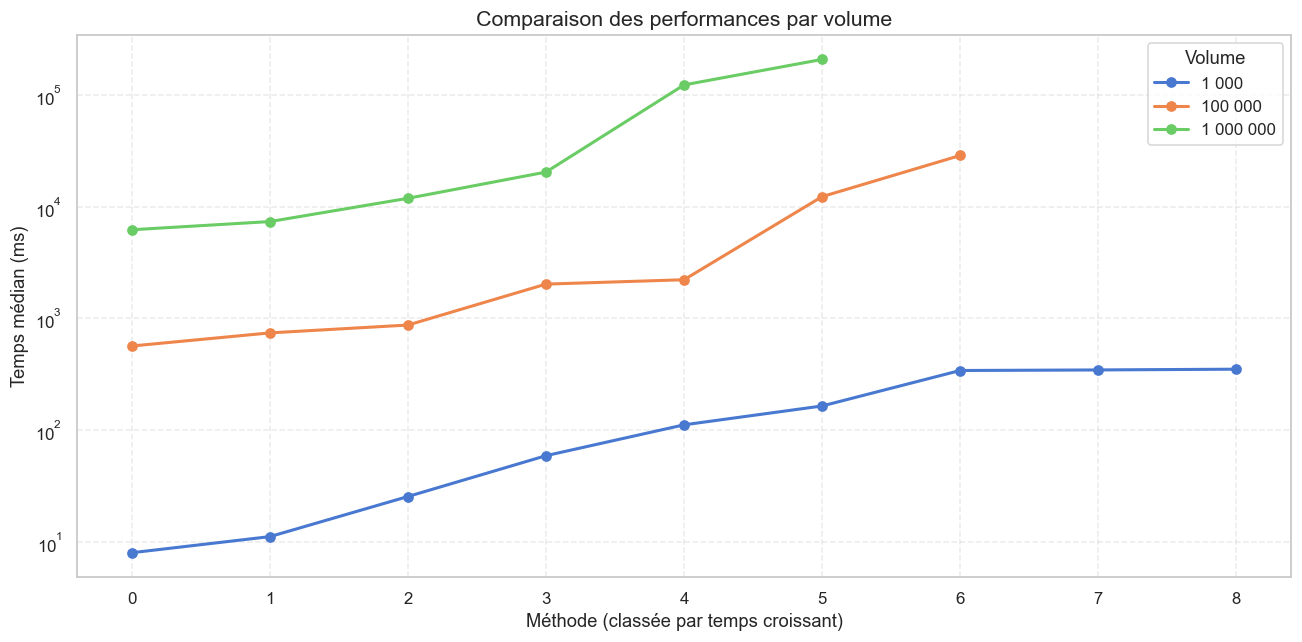

In [59]:
plt.figure(figsize=(12, 6))

tailles = {
    "1 000":     df_1k,
    "100 000":   df_100k,
    "1 000 000": df_1m,
}

for label, subset in tailles.items():
    means = subset.groupby("method")["duration"].median().sort_values() * 1000
    plt.plot(range(len(means)), means.values, marker="o", label=label, linewidth=2)

plt.title("Comparaison des performances par volume")
plt.xlabel("Méthode (classée par temps croissant)")
plt.ylabel("Temps médian (ms)")
plt.yscale("log")
plt.legend(title="Volume")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

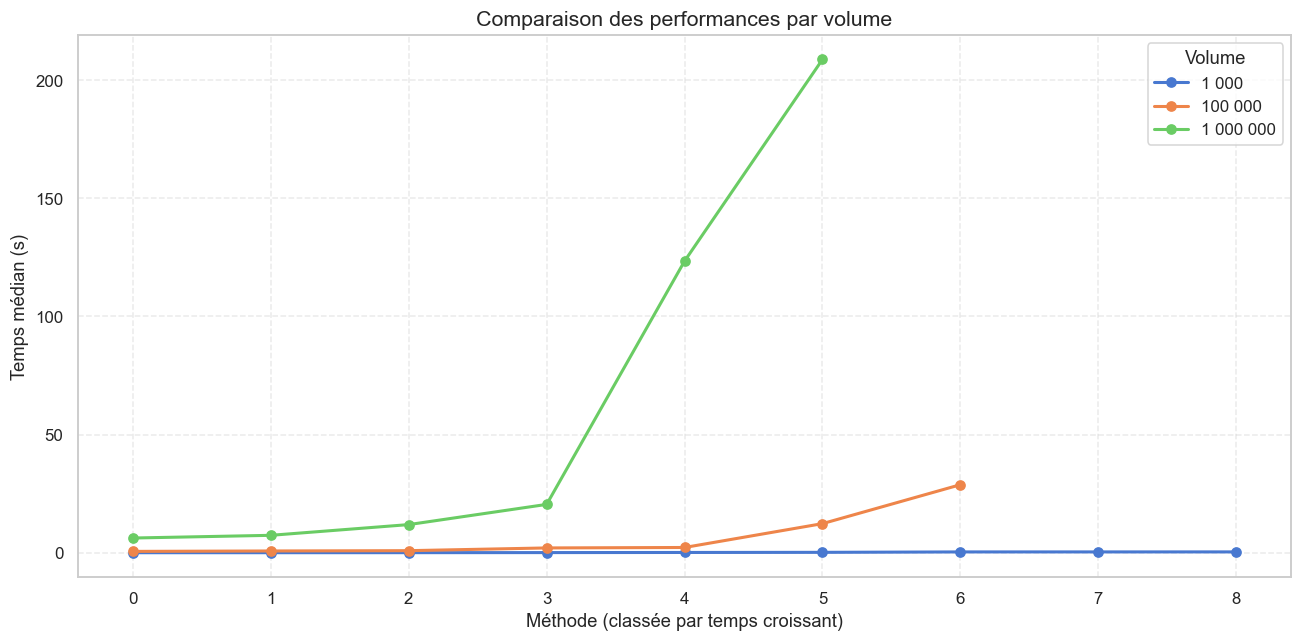

In [ ]:
plt.figure(figsize=(12, 6))

tailles = {
    "1 000":     df_1k,
    "100 000":   df_100k,
    "1 000 000": df_1m,
}

for label, subset in tailles.items():
    means = subset.groupby("method")["duration"].median().sort_values()
    plt.plot(range(len(means)), means.values, marker="o", label=label, linewidth=2)

plt.title("Comparaison des performances par volume")
plt.xlabel("Méthode (classée par temps croissant)")
plt.ylabel("Temps médian")
plt.legend(title="Volume")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

In [53]:
cursor.close()
conn.close()
print(" Connexion fermée")


 Connexion fermée
